In [1]:
from sympy import *
from delierium.infinitesimals import overdetermined_system_ode, janet_basis_from_ode
from delierium.janet_basis import JanetBasis
from delierium.helpers import is_derivative, eq, ltf
from delierium.matrix_order import Context
import functools
from operator import mul
from pprint import pprint

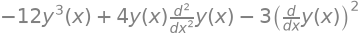

.........................


Janet basis


In [2]:
# Schwarz, Example 5.2, p. 200 (Kamke 6.159)
x = Symbol('x')
y = Function("y")(x)
d0 = y
d1 = diff(y, x)
d2 = diff(d1, x)
d3 = diff(d2, x)
d4 = diff(d3, x)
ode = 4*d2*d0 - 3*d1**2 - 12*d0**3
display(ode)

inf = overdetermined_system_ode(ode, [y], [x])
print("."*25)
for _ in inf:
    ltf(_, [y], [x])
print("Janet basis")
jb = janet_basis_from_ode(ode, y, x)
for _ in jb:
    _.show()

In [3]:
# B: Janet basis from Schwarz, Example 5.2, p. 200, with xi = X, eta = Y
from sympy import Function, Symbol, diff
from delierium.infinitesimals import is_janet_basis_of_ode
ys = Symbol("y")
X, Y = Function("X")(ys, x), Function("Y")(ys, x)
B = [
    diff(X, x) + Y/(2*ys),
    diff(X, ys),
    diff(Y, x),
    diff(Y, ys) - Y/ys,
]
print(is_janet_basis_of_ode(B, ode, y, x))

True
